# Lab 01：時間序列 feature engineering

## 問題與資料

Lab 00 把 `detector.py` 的 `rolling_zscore()` 接上即時流量，比較了三種視窗長度。這一節我們改用有 Ground Truth Events 標記的資料，以便於驗證結果。

本實驗使用一份 30 天的歷史資料：5 個 Port 的 SNMP 介面計數，取樣間隔 300 秒（共 43,200 列），內含 10 個事件（18 個獨立的事件×Port 時窗）。

> **環境設定：** 所有分析都在 Notebook 內完成，讀取 `data/synthetic/` 路徑下的 CSV 檔。不需要啟動 Prometheus、node_exporter、Grafana 或 `detector.py`。若 Lab 00 的服務仍在執行，直接關閉即可。

資料集裡有 10 個標記的 event（A 到 J），以及一份 change calendar。**計畫性變更在流量上與真實事故長得一模一樣**，必須被抑制而不是被偵測到。`event_id` 與 `event_label` 兩欄是 ground truth，只用來評分，不用來擬合。

原始欄位全部是 300 秒區間內的總量，不是累積 counter：

| 欄位 | 意義 | 角色 |
|---|---|---|
| `timestamp` | 輪詢時間，5 分鐘一次 | index |
| `device_id`, `port_id`, `port_role` | 哪一個介面，以及它的功能 | grouping key |
| `INOCTETS`, `OUTOCTETS` | 進 / 出 bytes | throughput |
| `INUCASTPKTS`, `OUTUCASTPKTS` | unicast 封包，進 / 出 | packet rate |
| `INNUCASTPKTS`, `OUTNUCASTPKTS` | non-unicast 封包，進 / 出 | packet rate |
| `INBROADCASTPKTS`, `OUTBROADCASTPKTS` | broadcast 封包 | L2 storm 的訊號 |
| `INMULTICASTPKTS`, `OUTMULTICASTPKTS` | multicast 封包 | flooding 的訊號 |
| `INERRORS`, `OUTERRORS` | frame error | link quality |
| `INDISCARDS`, `OUTDISCARDS` | 被丟棄的 frame | congestion |
| `INUNKNOWNPROTOS` | 無法辨識協定的 frame | scan 或設定錯誤 |
| `event_label`, `event_id` | 注入 event 的 ground truth | 只用於評分 |

`ERRORS` 與 `DISCARDS` 的區別要分清楚。前者是傳輸失敗，屬於硬體或線路層；後者是傳輸成功但被設備主動丟棄，屬於軟體或資源層。

本節進行 Feature Engineering，將結果存成 `outputs/workshop/features.csv` 交給 Lab 02。

| 步驟 | 大綱 |
|---|---|
| 1 | 載入 telemetry 與 ground truth |
| 2 | counter 轉成兩類 feature：volume 與 shape |
| 3 | scale profile：為什麼單一全域 threshold 必然錯 |
| 4 | zero-value profile：哪些欄位撐不起 z-score |
| 5 | distribution：z-score 在這一欄可信嗎 |
| 6 | autocorrelation：rolling window 長度的下限 |
| 7 | rolling baseline 與 robust z |
| 8 | feature correlation：哪兩欄是高相關 |
| 9 | event × feature heatmap：每個 feature 的盲點 |
| 10 | leave-one-out ablation 與 greedy forward selection |
| 11 | anomaly taxonomy |
| 12 | 存檔 |

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Georgia", "Times New Roman", "DejaVu Serif"],
    "figure.dpi": 110, "axes.titlesize": 10, "axes.titlelocation": "left",
    "axes.labelsize": 9, "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# Walk up from the working directory until we find the course root. The marker is
# the environments/ folder, so the notebook runs from any launch directory.
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "environments").is_dir():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "synthetic"
OUT = ROOT / "outputs" / "workshop"
OUT.mkdir(parents=True, exist_ok=True)

# One colour means one thing across every figure in both labs: blue is the measured
# signal, orange the baseline, purple a derived score, red an alert or a limit.
C = {"signal": "#3B7DD8", "baseline": "#E0752D", "score": "#7A5AC7",
     "alert": "#D6455D", "truth": "#FF9F1C", "peer": "#2E9E7B", "muted": "#9AA4B0"}

# Rescales the median absolute deviation so that, on normal data, it reads on the
# same "how many sigma" axis as a standard deviation.
MAD_TO_SIGMA = 1.4826

# Scores are clipped here. A near-zero denominator can produce an arbitrarily large
# score, and one such sample would otherwise flatten every other line on a plot.
MAX_SCORE = 50.0

print(f"course root  {ROOT}")

course root  /Users/kevin/Library/CloudStorage/GoogleDrive-kevin880987@gmail.com/我的雲端硬碟/workshop/workbench/project/202608-aia-network-monitoring-aiops/aiops-anomaly-zero-to-hero


## 第 1 步：載入 telemetry 與 ground truth

`synthetic_rrd_metrics.csv` 每一列是一個 port 在一個取樣區間內的計數總量。`synthetic_event_catalog.csv` 標出真的發生過 event 的時段。真實環境沒有這份檔案，這裡用它來驗證後面每一個選擇。

cadence 用量的，不用猜，因為後面所有 window 長度都由它換算。change calendar 再把 event 切成兩類：必須抓到的 incident，以及必須保持安靜的計畫性變更。

In [2]:
raw = (pd.read_csv(DATA / "synthetic_rrd_metrics.csv", parse_dates=["timestamp"])
         .sort_values(["device_id", "port_id", "timestamp"]).reset_index(drop=True))

# Measure the sampling interval instead of trusting a config value. The median gap
# is robust to the occasional missed or duplicated sample. Every window length below
# is expressed in samples, so a wrong cadence would silently rescale all of them.
CADENCE = float(raw.groupby("port_id")["timestamp"].diff().dt.total_seconds().median())
WINDOW = int(round(3600 / CADENCE))     # one hour, expressed in samples
DAY = int(round(86400 / CADENCE))       # one day, expressed in samples

# Ground truth. The simulator tagged every sample that belongs to an event, so
# collapsing those tagged rows gives one (start, end) window per (event, port).
# Events G and H hit all five ports at once, which is why 10 events become 18 windows.
events = (raw[raw["event_label"] != "normal"]
          .groupby(["event_id", "event_label", "device_id", "port_id", "port_role"], observed=True)
          .agg(start=("timestamp", "min"), end=("timestamp", "max"), n=("timestamp", "size"))
          .reset_index().rename(columns={"event_label": "event_type"})
          .sort_values("start").reset_index(drop=True))

# The change calendar is the only thing that separates a real incident from a
# declared maintenance window. Nothing in the telemetry itself tells them apart.
calendar = (pd.read_csv(DATA / "change_calendar.csv", parse_dates=["start_time", "end_time"])
              .rename(columns={"start_time": "start", "end_time": "end"}))


def in_scope(scope, device_id, port_id):
    """A calendar entry covers this port if its scope names the port, the device, or everything."""
    return str(scope) in ("ALL", "*", str(device_id), str(port_id))


# Mark every event window that overlaps a declared change in both scope and time.
planned = pd.Series(False, index=events.index)
for ch in calendar.itertuples():
    for i, e in events.iterrows():
        if in_scope(ch.scope, e.device_id, e.port_id) and e.start <= ch.end and e.end >= ch.start:
            planned.loc[i] = True
events["planned"] = planned

# incidents is the denominator of every recall number in both labs. Planned changes
# are deliberately excluded: staying quiet during them is correct behaviour, not a miss.
incidents = events[~events["planned"]].reset_index(drop=True)

BASE_RATE = float((raw["event_label"] != "normal").mean())
print(f"{len(raw):,} rows | {raw.port_id.nunique()} ports | cadence {CADENCE:.0f}s "
      f"| 1h = {WINDOW} samples | 1d = {DAY} samples")
print(f"{len(events)} event windows, {len(incidents)} must be caught, "
      f"{int(events.planned.sum())} are planned changes | base rate {BASE_RATE:.2%}")
print(f"shortest event = {int(events.n.min())} samples  "
      f"<- hard ceiling on the confirmation length N used in Lab 02")
display(events)

43,200 rows | 5 ports | cadence 300s | 1h = 12 samples | 1d = 288 samples
18 event windows, 16 must be caught, 2 are planned changes | base rate 0.66%
shortest event = 8 samples  <- hard ceiling on the confirmation length N used in Lab 02


,event_id,event_type,device_id,port_id,port_role,start,end,n,planned
0,A,business_traffic_growth,core-sw-01,port-id7430,office-vlan,2026-02-04 09:00:00,2026-02-04 10:55:00,24,True
1,B,small_packet_scan,edge-fw-01,port-id7428,wan-secondary,2026-02-06 13:10:00,2026-02-06 13:55:00,10,False
2,C,large_file_backup,dist-sw-02,port-id7431,backup-storage,2026-02-08 01:00:00,2026-02-08 03:55:00,36,True
3,D,queue_congestion,edge-fw-01,port-id7427,wan-primary,2026-02-11 15:20:00,2026-02-11 16:25:00,14,False
4,E,link_quality_issue,core-sw-01,port-id7429,server-uplink,2026-02-14 10:35:00,2026-02-14 11:10:00,8,False
5,F,load_sensitive_link_issue,edge-fw-01,port-id7427,wan-primary,2026-02-17 16:00:00,2026-02-17 17:25:00,18,False
6,G,broadcast_storm,edge-fw-01,port-id7428,wan-secondary,2026-02-19 11:30:00,2026-02-19 12:25:00,12,False
7,G,broadcast_storm,edge-fw-01,port-id7427,wan-primary,2026-02-19 11:30:00,2026-02-19 12:25:00,12,False
8,G,broadcast_storm,dist-sw-02,port-id7431,backup-storage,2026-02-19 11:30:00,2026-02-19 12:25:00,12,False
9,G,broadcast_storm,core-sw-01,port-id7430,office-vlan,2026-02-19 11:30:00,2026-02-19 12:25:00,12,False


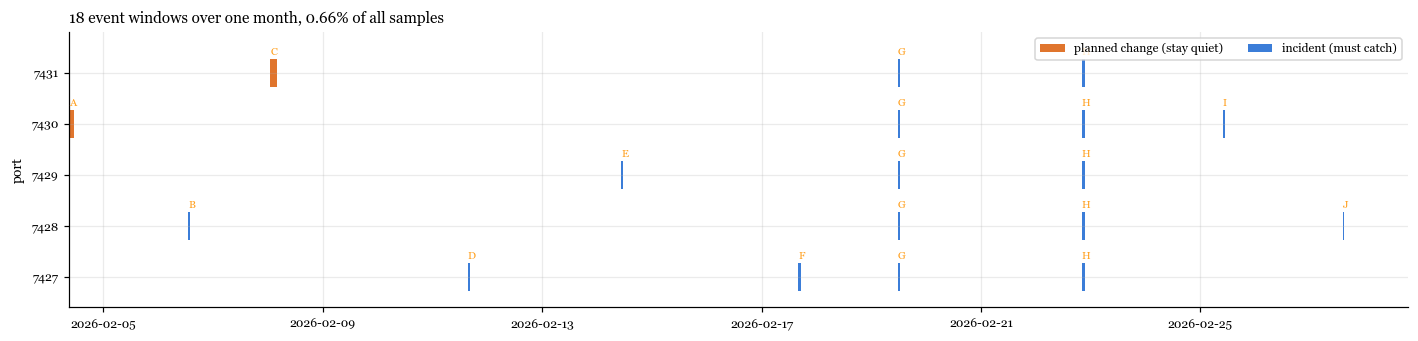

In [3]:
def shade(ax, time, mask, color=None, label="event"):
    """Shade every contiguous run of True in `mask`, collapsing them into one legend entry.

    Used on every time-series plot in both labs so the ground-truth windows are always
    marked the same way and can be compared across figures by eye.
    """
    v = np.asarray(pd.Series(mask).fillna(False), dtype=bool)
    idx = np.flatnonzero(v)
    if idx.size == 0:
        return
    brk = np.flatnonzero(np.diff(idx) > 1)          # a jump larger than 1 starts a new run
    starts, ends = np.r_[idx[0], idx[brk + 1]], np.r_[idx[brk], idx[-1]]
    t = pd.Series(time).reset_index(drop=True)
    for n, (a, b) in enumerate(zip(starts, ends)):
        ax.axvspan(t.iloc[a], t.iloc[b], color=color or C["truth"], alpha=0.3,
                   lw=0, zorder=0, label=label if n == 0 else None)


# Gantt view of the whole month. Blue and orange bars are the same shape in the raw
# traffic; only the calendar tells you which one should page somebody.
ports = sorted(raw["port_id"].unique())
fig, ax = plt.subplots(figsize=(13, 3.2))
for e in events.itertuples():
    ax.barh(ports.index(e.port_id), e.end - e.start, left=e.start, height=0.55,
            color=C["baseline"] if e.planned else C["signal"],
            label="planned change (stay quiet)" if e.planned else "incident (must catch)")
    ax.text(e.start, ports.index(e.port_id) + 0.35, e.event_id, fontsize=7, color=C["truth"])
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))                    # one legend entry per class, not per bar
ax.legend(uniq.values(), uniq.keys(), loc="upper right", ncol=2)
ax.set_yticks(range(len(ports)), [p[-4:] for p in ports])
ax.set_ylim(-0.6, len(ports) - 0.2)
ax.set(xlabel="", ylabel="port",
       title=f"{len(events)} event windows over one month, {BASE_RATE:.2%} of all samples")
fig.tight_layout(); plt.show()

## 第 2 步：counter 轉成兩族 feature

除以 cadence 得到每秒速率，再組成兩個家族。**volume** 回答「有多少」，**shape** 回答「是什麼樣的流量」。單一原始 counter 無法同時回答兩者，第 9 步會看到忽略這個分離要付的代價。

下面把原始欄位與工程後的訊號並排。左邊是直接從 CSV 讀出來的兩欄，右邊是偵測器實際會計分的那一條。兩邊的形狀相近，因為 feature engineering 沒有改變發生過什麼，只改變了什麼量得到；真正被改變的是可比較性，而左圖標的 IN share 說明了為什麼單看一欄不夠。


In [4]:
RAW_COLS = ["INOCTETS", "OUTOCTETS", "INUCASTPKTS", "OUTUCASTPKTS", "INNUCASTPKTS",
            "OUTNUCASTPKTS", "INBROADCASTPKTS", "OUTBROADCASTPKTS", "INMULTICASTPKTS",
            "OUTMULTICASTPKTS", "INERRORS", "OUTERRORS", "INDISCARDS", "OUTDISCARDS",
            "INUNKNOWNPROTOS"]

tel = raw[["timestamp", "device_id", "port_id", "port_role", "event_label", "event_id"]].copy()

# Each raw row already holds the total accumulated within one polling interval, so the
# per-second rate is just the value divided by the cadence. This is the only unit
# conversion in the lab; no differencing is involved.
r = raw[RAW_COLS].astype(float) / CADENCE

eps = 1e-9                                           # guards every ratio denominator
rx, tx = r["INOCTETS"], r["OUTOCTETS"]
ucast = r["INUCASTPKTS"] + r["OUTUCASTPKTS"]         # one-to-one traffic
nucast = r["INNUCASTPKTS"] + r["OUTNUCASTPKTS"]      # legacy MIB: broadcast + multicast combined
bcast = r["INBROADCASTPKTS"] + r["OUTBROADCASTPKTS"]
mcast = r["INMULTICASTPKTS"] + r["OUTMULTICASTPKTS"]
errors = r["INERRORS"] + r["OUTERRORS"]              # transmission failures, hardware or cabling
discards = r["INDISCARDS"] + r["OUTDISCARDS"]        # delivered but dropped, congestion or QoS
packets = ucast + nucast
all_pkts = packets + bcast + mcast

# Volume family: how much is flowing. Direction is merged because a fault rarely
# respects it, and keeping both directions doubles the columns without adding evidence.
tel["traffic_bps"] = rx + tx
tel["packets_pps"] = packets
tel["errors_pps"] = errors
tel["discards_pps"] = discards
tel["unknown_proto_pps"] = r["INUNKNOWNPROTOS"]

# Shape family: what kind of traffic it is. Every one of these is a ratio, so it is
# already scale free and comparable across ports of very different sizes.
tel["avg_pkt_bytes"] = (rx + tx) / (all_pkts + eps)          # large = bulk transfer, small = scan
tel["broadcast_ratio"] = bcast / (all_pkts + eps)            # ARP storm, switching loop
tel["multicast_ratio"] = mcast / (all_pkts + eps)            # IGMP problems, flooding
tel["nonucast_ratio"] = (bcast + mcast) / (all_pkts + eps)   # the two floods as one signal
tel["tx_ratio"] = tx / (rx + tx + eps)                       # direction balance, 0.5 = symmetric
tel["error_rate"] = errors / (packets + eps)
tel["discard_rate"] = discards / (packets + eps)
tel["err_disc_rate"] = (errors + discards) / (packets + eps)  # link quality as one number

VOLUME = ["traffic_bps", "packets_pps", "errors_pps", "discards_pps", "unknown_proto_pps"]
SHAPE = ["avg_pkt_bytes", "broadcast_ratio", "multicast_ratio", "nonucast_ratio",
         "tx_ratio", "error_rate", "discard_rate", "err_disc_rate"]
FEATURES = VOLUME + SHAPE

tel["is_event"] = tel["event_label"] != "normal"     # per-sample ground truth, used by every plot
display(tel[["timestamp", "port_id"] + FEATURES].head(3))

,timestamp,port_id,traffic_bps,packets_pps,errors_pps,discards_pps,unknown_proto_pps,avg_pkt_bytes,broadcast_ratio,multicast_ratio,nonucast_ratio,tx_ratio,error_rate,discard_rate,err_disc_rate
0,2026-02-01 00:00:00,port-id7429,21525.205133,18.490000,0.0,0.0,0.0,1155.198844,0.002683,0.005009,0.007692,0.649177,0.0,0.0,0.0
1,2026-02-01 00:05:00,port-id7429,18405.044233,19.143333,0.0,0.0,0.0,954.123599,0.002765,0.004838,0.007603,0.636731,0.0,0.0,0.0
2,2026-02-01 00:10:00,port-id7429,20414.775567,19.636667,0.0,0.0,0.0,1031.744048,0.002695,0.004885,0.007581,0.603459,0.0,0.0,0.0


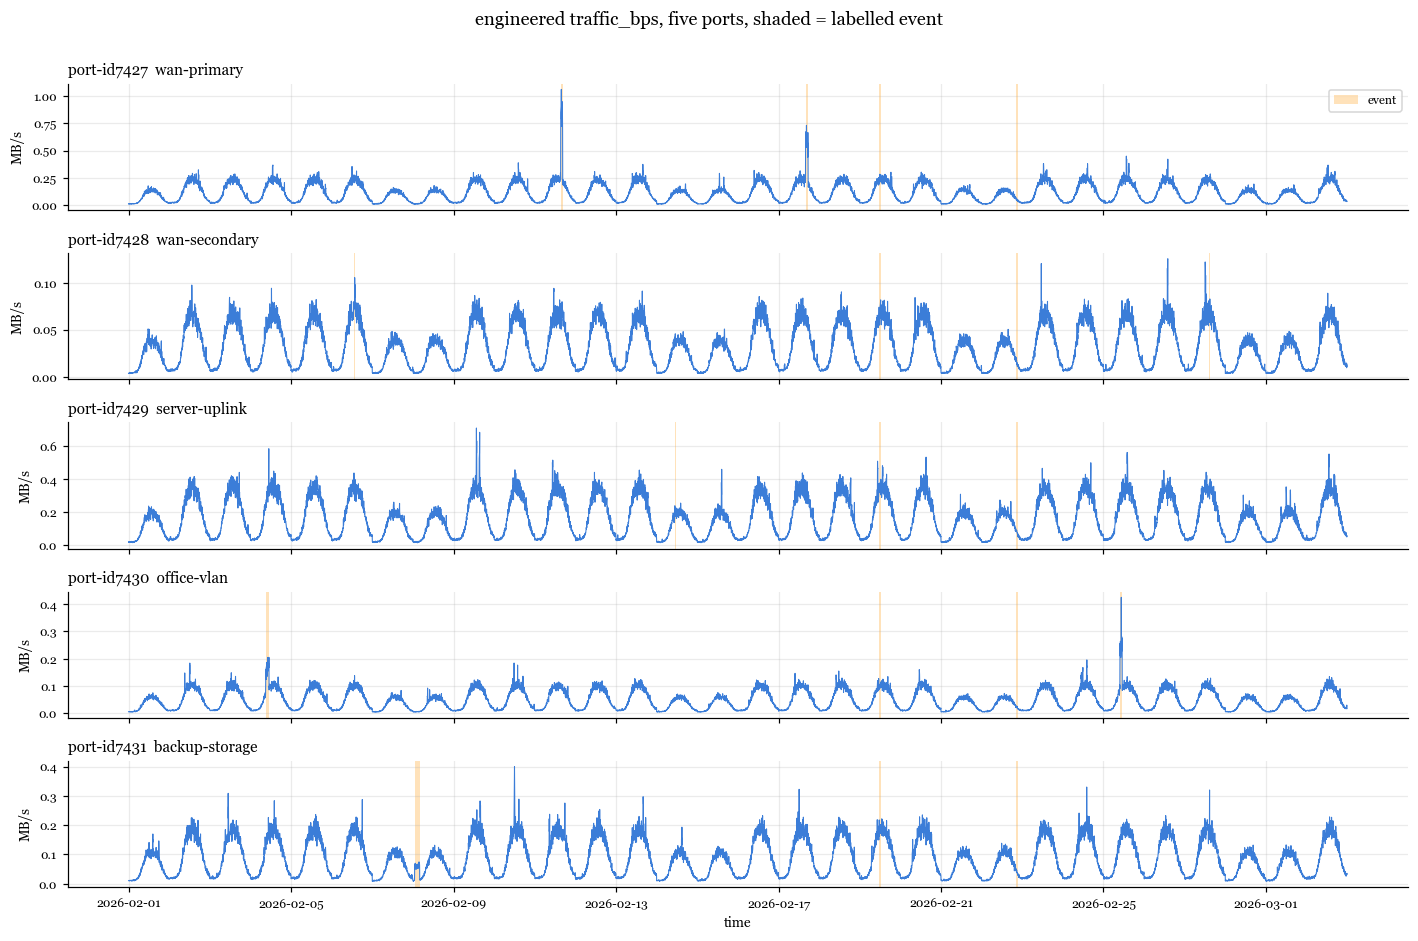

In [5]:
# Raw against engineered, one row per port. Left is a single column read straight out of
# the CSV; right is what the detector will actually score. The shapes rhyme, which is the
# point: engineering did not change what happened, only what is measurable. What it did
# change is comparability, and the IN share printed on each left panel says why one raw
# column is not the signal. On a port that sends more than it receives, INOCTETS alone
# tracks the smaller half of the traffic.
fig, axes = plt.subplots(len(ports), 2, figsize=(14, 1.9 * len(ports)), sharex=True)
for (left, right), p in zip(axes, ports):
    r_one = raw[raw["port_id"] == p]
    e_one = tel[tel["port_id"] == p]
    role = e_one["port_role"].iloc[0]
    in_share = r_one["INOCTETS"].sum() / (r_one["INOCTETS"].sum() + r_one["OUTOCTETS"].sum())

    left.plot(r_one["timestamp"], r_one["INOCTETS"] / 1e6, color=C["muted"], lw=0.7,
              label="INOCTETS")
    left.plot(r_one["timestamp"], r_one["OUTOCTETS"] / 1e6, color=C["baseline"], lw=0.7,
              label="OUTOCTETS")
    left.set(ylabel="MB / interval",
             title=f"raw  {p}  {role}   IN share {in_share:.0%}")

    right.plot(e_one["timestamp"], e_one["traffic_bps"] / 1e6, color=C["signal"], lw=0.7,
               label="traffic_bps")
    right.set(ylabel="MB/s", title=f"engineered  {p}")

    for ax in (left, right):
        shade(ax, e_one["timestamp"], e_one["is_event"])
axes[0, 0].legend(loc="upper right", ncol=3)
axes[0, 1].legend(loc="upper right", ncol=2)
for ax in axes[-1]:
    ax.set_xlabel("time")
fig.suptitle("raw counter columns against the engineered rate, shaded = labelled event",
             y=1.001)
fig.tight_layout(); plt.show()

### 探索練習：換一個欄位看同一個月

**任務**：把繪圖那一格的 `traffic_bps` 換成 `broadcast_ratio`，再換成 `avg_pkt_bytes`。

```python
ax.plot(one["timestamp"], one["broadcast_ratio"], color=C["signal"], lw=0.7)
```

觀察：

- 同一批陰影時段，三次浮出水面的是不是同一批 event？
- 哪一個欄位讓最多 event 用肉眼就看得出來？

**討論**：ratio 的分母是選出來的。`error_rate` 用 `packets`，`broadcast_ratio` 用 `all_pkts`，換一個分母就換了一個問題。IN 與 OUT 在這裡被合併掉了，`tx_ratio` 是唯一還看得到方向的欄位。

## 第 3 步：scale profile

五個 port 的流量規模跨越數倍，橫跨三個實體設備。任何「流量大於 X Mbps 就 alert」的規則，對至少一部分 port 必然是錯的。

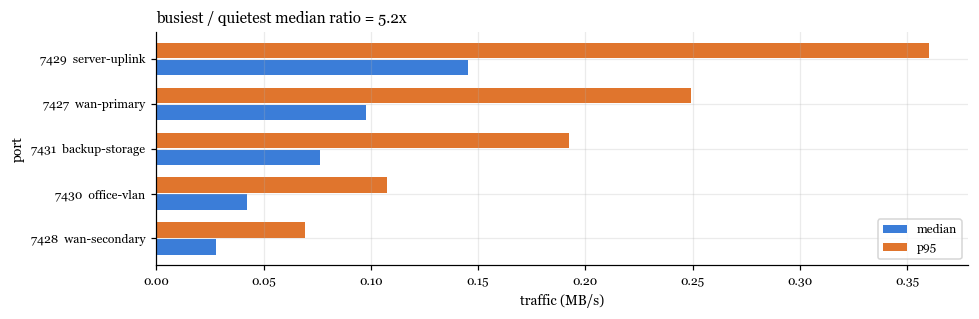

In [6]:
# Median and p95 per port. Median says where the port normally sits, p95 says how far
# its ordinary busy periods reach, and the gap between them differs by port too.
scale = (tel.groupby(["device_id", "port_id", "port_role"], observed=True)["traffic_bps"]
         .agg(median="median", p95=lambda s: s.quantile(0.95)).reset_index()
         .sort_values("median"))
scale[["median", "p95"]] /= 1e6                      # bytes/s to MB/s, easier to read on the axis

y = np.arange(len(scale))
fig, ax = plt.subplots(figsize=(9, 3.0))
ax.barh(y - 0.19, scale["median"], height=0.34, color=C["signal"], label="median")
ax.barh(y + 0.19, scale["p95"], height=0.34, color=C["baseline"], label="p95")
ax.set_yticks(y, [f"{t.port_id[-4:]}  {t.port_role}" for t in scale.itertuples()])
ax.set(xlabel="traffic (MB/s)", ylabel="port",
       title=f"busiest / quietest median ratio = {scale['median'].max() / scale['median'].min():.1f}x")
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

### 探索練習：scale 差異與離散程度是兩件事

**任務**：把長條圖改成畫 `p95 / median` 的比值。

```python
scale["ratio"] = scale["p95"] / scale["median"]
```

觀察：

- 流量最大的 port，離散程度也最大嗎？
- 兩張圖的排序一樣嗎？

**討論**：normalization 只解決 scale 差異，不解決離散程度差異。p95 這個分位數也是任意選的，改成 p99 會把偶發尖峰算進「正常的忙碌」。

## 第 4 步：zero-value profile：哪些欄位撐不起 z-score

$(x - \text{center}) / \text{scale}$ 需要有意義的離散度。當一欄大半時間貼在零，rolling scale 會塌到下限，任何非零讀數都會被一個接近零的數字除，產生巨大而無意義的 score。

這個劃分要在選 baseline **之前**做完，因為 degenerate 是欄位分佈的性質，不是它單位的性質。

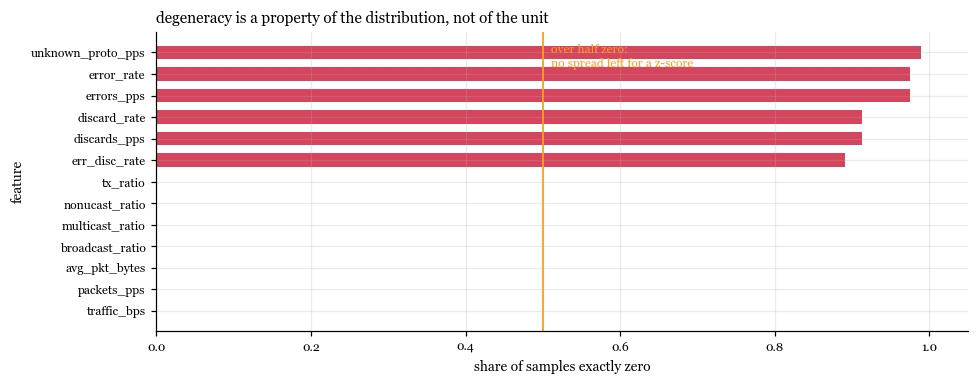

scorable  : ['traffic_bps', 'packets_pps', 'avg_pkt_bytes', 'broadcast_ratio', 'multicast_ratio', 'nonucast_ratio', 'tx_ratio']
degenerate: ['err_disc_rate', 'discards_pps', 'discard_rate', 'errors_pps', 'error_rate', 'unknown_proto_pps']


In [7]:
# The practical test for whether a z-score means anything on a column: once too many
# samples sit at exactly zero, there is no spread left for the denominator to estimate.
zero_frac = (tel[FEATURES] == 0).mean().sort_values()
DEGENERATE = zero_frac[zero_frac > 0.5].index.tolist()
SCORABLE = [f for f in FEATURES if f not in DEGENERATE]

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(range(len(zero_frac)), zero_frac.to_numpy(),
        color=[C["alert"] if v > 0.5 else C["signal"] for v in zero_frac], height=0.62)
ax.axvline(0.5, color=C["truth"], lw=1.2)
ax.text(0.51, len(zero_frac) - 0.6, "over half zero:\nno spread left for a z-score",
        fontsize=8, color=C["truth"], va="top")
ax.set_yticks(range(len(zero_frac)), zero_frac.index, fontsize=8)
ax.set(xlim=(0, 1.05), xlabel="share of samples exactly zero", ylabel="feature",
       title="degeneracy is a property of the distribution, not of the unit")
fig.tight_layout(); plt.show()

print("scorable  :", SCORABLE)
print("degenerate:", DEGENERATE)

### 探索練習：0.5 這條界線是你設的

**任務**：把 degenerate 的判準改成 0.3，再改成 0.8。

```python
DEGENERATE = zero_frac[zero_frac > 0.3].index.tolist()
```

觀察：

- `SCORABLE` 的名單各差幾欄？
- 第 10 步的 ablation 結論會跟著變嗎？

**討論**：這裡用「剛好等於零的比例」當判準，另一個判準是量 rolling scale 貼到下限的比例，那個更貼近失效的機制，但要先算完 baseline 才知道。先算便宜的，還是先算準的？另外，判準套在全體資料上，某個 port 有離散度而其他四個沒有，現在會被一起判成 degenerate。

## 第 5 步：distribution：z-score 在這一欄可信嗎

直方圖疊一條同 mean 同 standard deviation 的 normal reference curve。兩者的差距，就是 z-score 在這一欄可以被信任的程度。

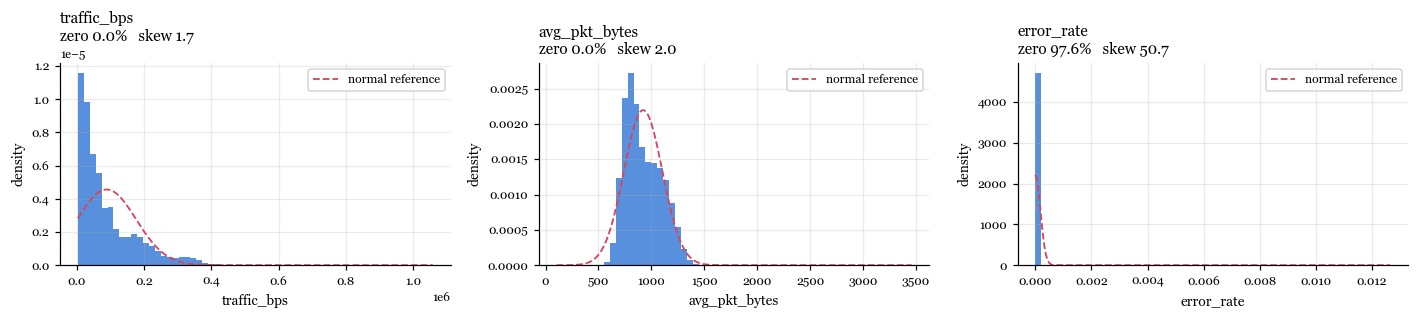

In [8]:
# Overlaying a matched normal curve turns "is a z-score meaningful here" into something
# you can see. A good fit means the sigma axis is trustworthy; a spike at zero means
# this column needs a fixed threshold instead.
show = ["traffic_bps", "avg_pkt_bytes", "error_rate"]
fig, axes = plt.subplots(1, len(show), figsize=(13, 3.0))
for ax, col in zip(axes, show):
    v = tel[col].dropna()
    ax.hist(v, bins=60, density=True, color=C["signal"], alpha=0.85)
    mu, sd = v.mean(), v.std()
    grid = np.linspace(v.min(), v.max(), 200)
    ax.plot(grid, np.exp(-0.5 * ((grid - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi)),
            color=C["alert"], ls="--", lw=1.2, label="normal reference")
    ax.legend()
    ax.set(xlabel=col, ylabel="density",
           title=f"{col}\nzero {(v == 0).mean():.1%}   skew {v.skew():.1f}")
fig.tight_layout(); plt.show()

### 探索練習：換一個 scale 再看一次分佈

**任務**：把直方圖的資料改成取對數。

```python
v = np.log1p(tel[col].dropna())
```

觀察：

- normal reference curve 貼合得多好？
- 零附近那根尖峰消失了嗎？

**討論**：貼合了就代表在對數 scale 上計分比較合理。normal reference curve 是最粗的檢查，QQ plot 對尾端更敏感；在 43,200 筆上任何常態檢定都會拒絕，所以圖比 p-value 有用。

## 第 6 步：autocorrelation：rolling window 長度的下限

一個代表「正常」的 rolling window，長度必須跨越至少一個最強週期，否則它會把正常的日節律當成偏離，每天固定產生一次 false alarm。

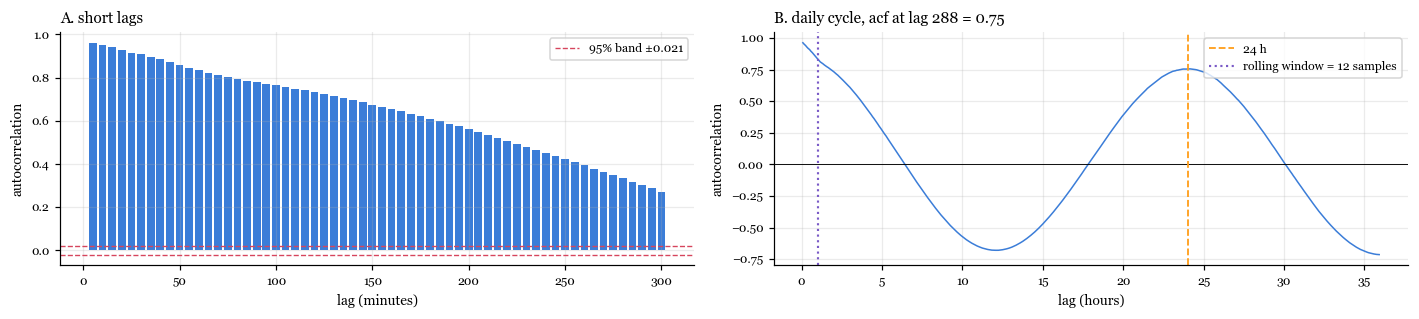

In [9]:
# Autocorrelation says how long this series keeps resembling its own past. Anything
# above the white-noise band is real structure that a rolling window has to respect.
s = tel[tel["port_id"] == ports[0]]["traffic_bps"].reset_index(drop=True)
lags = np.arange(1, 3 * DAY // 2)
acf = np.array([s.autocorr(lag=int(k)) for k in lags])
conf = 1.96 / np.sqrt(len(s))                        # 95% band under the white-noise null

fig, axes = plt.subplots(1, 2, figsize=(13, 3.0))
short = lags <= 60                                   # panel A zooms into the first few hours
axes[0].bar(lags[short] * CADENCE / 60, acf[short], width=CADENCE / 60 * 0.8,
            color=[C["signal"] if abs(v) > conf else C["muted"] for v in acf[short]])
axes[0].axhline(conf, color=C["alert"], ls="--", lw=0.9, label=f"95% band ±{conf:.3f}")
axes[0].axhline(-conf, color=C["alert"], ls="--", lw=0.9)
axes[0].set(xlabel="lag (minutes)", ylabel="autocorrelation", title="A. short lags")
axes[0].legend()

axes[1].plot(lags * CADENCE / 3600, acf, color=C["signal"], lw=1.0)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].axvline(24, color=C["truth"], ls="--", lw=1.2, label="24 h")
axes[1].axvline(WINDOW * CADENCE / 3600, color=C["score"], ls=":", lw=1.4,
                label=f"rolling window = {WINDOW} samples")
axes[1].set(xlabel="lag (hours)", ylabel="autocorrelation",
            title=f"B. daily cycle, acf at lag {DAY} = {acf[DAY - 1]:.2f}")
axes[1].legend()
fig.tight_layout(); plt.show()

### 探索練習：把 window 拉長到一整天

**任務**：把第 7 步的 `WINDOW` 從 12 改成 288，重新執行第 7 步。

```python
WINDOW = 288   # 一整天，而不是一小時
```

觀察：

- 日節律造成的偏離消失了嗎？
- 比 window 還長的 event（例如 event C，36 筆）還看得見嗎？

**討論**：兩難的出口不是調長度，是換一種比較對象，也就是 Lab 02 第 2 步的 seasonal baseline。這一格只畫了 `ports[0]`，五個 port 的日週期強度不一樣，office-vlan 的節律遠比 backup-storage 明顯。

## 第 7 步：rolling baseline 與 robust z

同一個殼 $(x - \text{center}) / \text{scale}$，換兩種估計法：

| | center | scale | 對 window 內的 outlier |
|---|---|---|---|
| `rolling mean` | mean | standard deviation | 第一個 outlier 就被拉走 |
| `rolling robust` | median | MAD × 1.4826 | 污染過半之前不動 |

scale 再加一個下限，避免安靜時段的分母塌到零。

In [10]:
def floor_of(values, fraction=0.05):
    """Lower bound for any score denominator, set at a fraction of the whole series' spread.

    Without it a quiet stretch drives the rolling scale toward zero and every ordinary
    wobble divides into a huge score. The fallbacks handle a series whose MAD is exactly
    zero, which happens on columns that are mostly constant.
    """
    x = np.asarray(values, float)
    x = x[np.isfinite(x)]
    mad = float(np.median(np.abs(x - np.median(x)))) * MAD_TO_SIGMA
    if mad <= 0:
        mad = float(np.std(x)) or 0.01 * float(np.mean(np.abs(x))) or 1e-12
    return max(fraction * mad, 1e-12)


def rolling_mean(v, w):
    """Center and scale from the arithmetic mean and the standard deviation of the window."""
    mp = max(3, w // 3)                              # need a third of the window before reporting
    return v.rolling(w, min_periods=mp).mean(), v.rolling(w, min_periods=mp).std()


def rolling_robust(v, w):
    """Center and scale from the median and the MAD, both order statistics.

    The median does not move until more than half the window is contaminated, which is
    exactly the failure mode that breaks the mean during a sustained event.
    """
    mp = max(3, w // 3)
    center = v.rolling(w, min_periods=mp).median()
    mad = (v - center).abs().rolling(w, min_periods=mp).median() * MAD_TO_SIGMA
    return center, mad


def z_of(v, center, scale):
    """Standardise to (value - center) / scale, with the floor applied and the result capped."""
    f = floor_of(v)
    return ((v - center) / scale.fillna(f).clip(lower=f)).clip(-MAX_SCORE, MAX_SCORE)


# Every baseline is computed per port. Mixing ports would let a busy port's numbers
# define what counts as normal for a quiet one, which is the failure step 3 illustrated.
parts = []
for pid, g in tel.groupby("port_id", observed=True):
    g = g.sort_values("timestamp").copy()
    new = {}
    for col in FEATURES:
        v = g[col].astype(float)
        m, sd = rolling_mean(v, WINDOW)
        med, mad = rolling_robust(v, WINDOW)
        new[f"{col}__mean"] = m                      # kept for the comparison plot below
        new[f"{col}__std"] = sd
        new[f"{col}__center"] = med
        new[f"{col}__scale"] = mad
        new[f"z_{col}"] = z_of(v, med, mad)          # the robust score Lab 02 starts from
    # Build the new columns in one frame and concat once, rather than inserting them
    # one at a time into a 43k-row frame.
    parts.append(pd.concat([g, pd.DataFrame(new, index=g.index)], axis=1))
tel = pd.concat(parts).sort_index()
print(f"{len([c for c in tel.columns if c.startswith('z_')])} robust z columns added")

13 robust z columns added


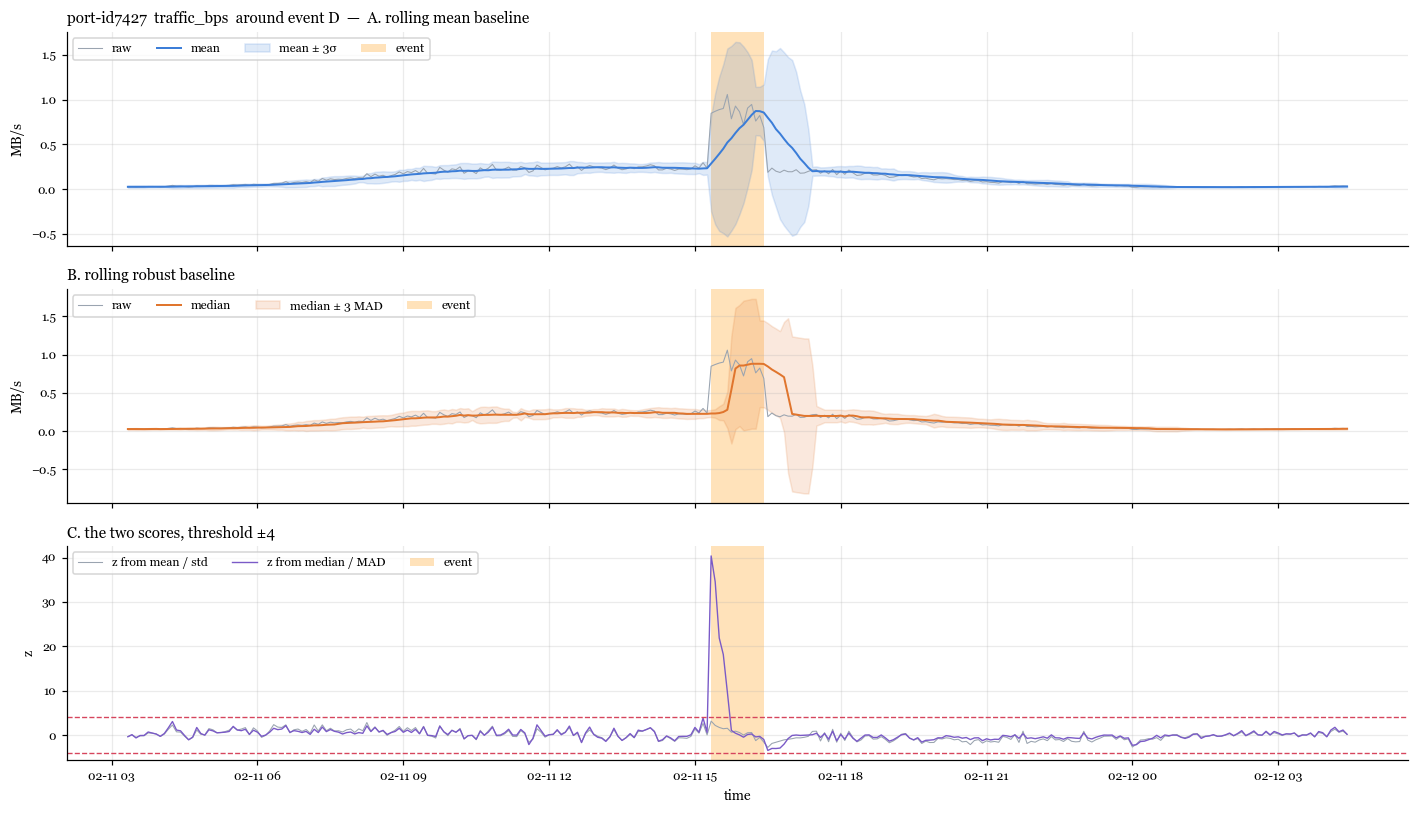

In [11]:
# Same port, same feature, three views: the two baselines drawn as expected ranges, then
# the two scores they produce on one axis so the difference is directly comparable.
# A whole month at this cadence is 8,640 points per port and the two lines would sit on
# top of each other, so zoom to one event with a day of context on either side.
COL = "traffic_bps"
ev = events[events.event_id == "D"].iloc[0]
p = tel[(tel["port_id"] == ev.port_id)
        & tel["timestamp"].between(ev.start - pd.Timedelta("12h"), ev.end + pd.Timedelta("12h"))
        ].sort_values("timestamp")
PORT = ev.port_id

fig, axes = plt.subplots(3, 1, figsize=(13, 7.5), sharex=True)
axes[0].plot(p["timestamp"], p[COL] / 1e6, color=C["muted"], lw=0.7, label="raw")
axes[0].plot(p["timestamp"], p[f"{COL}__mean"] / 1e6, color=C["signal"], lw=1.3, label="mean")
axes[0].fill_between(p["timestamp"], (p[f"{COL}__mean"] - 3 * p[f"{COL}__std"]) / 1e6,
                     (p[f"{COL}__mean"] + 3 * p[f"{COL}__std"]) / 1e6,
                     color=C["signal"], alpha=0.16, label="mean ± 3σ")
axes[0].set(ylabel="MB/s", title=f"{PORT}  {COL}  around event D  —  A. rolling mean baseline")

axes[1].plot(p["timestamp"], p[COL] / 1e6, color=C["muted"], lw=0.7, label="raw")
axes[1].plot(p["timestamp"], p[f"{COL}__center"] / 1e6, color=C["baseline"], lw=1.3, label="median")
axes[1].fill_between(p["timestamp"], (p[f"{COL}__center"] - 3 * p[f"{COL}__scale"]) / 1e6,
                     (p[f"{COL}__center"] + 3 * p[f"{COL}__scale"]) / 1e6,
                     color=C["baseline"], alpha=0.16, label="median ± 3 MAD")
axes[1].set(ylabel="MB/s", title="B. rolling robust baseline")

axes[2].plot(p["timestamp"], z_of(p[COL], p[f"{COL}__mean"], p[f"{COL}__std"]),
             color=C["muted"], lw=0.7, label="z from mean / std")
axes[2].plot(p["timestamp"], p[f"z_{COL}"], color=C["score"], lw=0.9, label="z from median / MAD")
for level in (4, -4):
    axes[2].axhline(level, color=C["alert"], ls="--", lw=0.9)
axes[2].set(ylabel="z", xlabel="time", title="C. the two scores, threshold ±4")

for ax in axes:
    shade(ax, p["timestamp"], p["is_event"])
    ax.legend(loc="upper left", ncol=4)
fig.tight_layout(); plt.show()

### 探索練習：window 長度的影響

**任務**：把 `WINDOW` 從 `12`（1 小時）改成 `6`（30 分鐘），重新執行這兩格。

```python
WINDOW = 6
```

觀察：

- rolling mean 的曲線是不是更抖？
- expected range 是不是變窄了？
- 已知 event 時段更明顯，還是冒出更多 false alarm？

**討論**：window 越短偵測越敏感，false alarm 也越多，你的環境偏向哪一側？這一格還有三個寫死的常數：`min_periods = w // 3`、floor 的 `fraction = 0.05`、`MAX_SCORE = 50`。mean/std 與 median/MAD 只是 center 與 scale 的兩種估計法，IQR、trimmed mean、Huber 都能插進同一個殼。

## 第 8 步：feature correlation：哪兩欄是同一份證據

用 Spearman rank correlation，因為這種 telemetry 偏態嚴重，Pearson 會被少數極端值主導。

兩個高度相關的 feature 分開計分，只是把同一份證據數了兩次，false alarm 加倍而偵測力沒有增加。這也是後面跨 feature 取最大值而不是加總的理由。

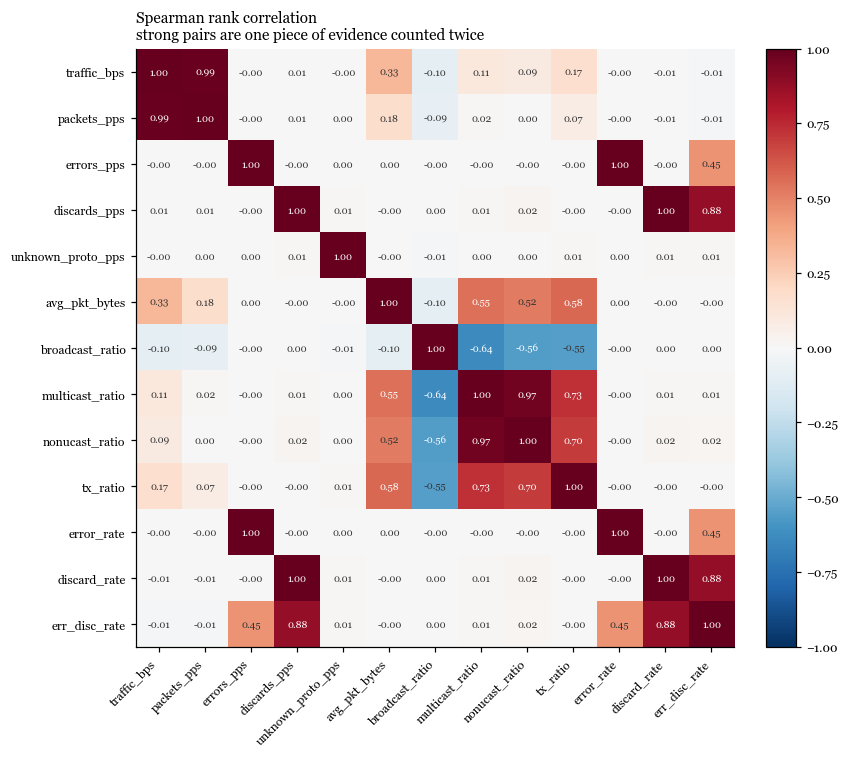

In [12]:
# Rank correlation, not linear correlation: ranks are unaffected by the heavy right tail
# that every traffic column has, so the number reflects co-movement rather than outliers.
corr = tel[FEATURES].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.4, 7.0))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(FEATURES)), FEATURES, fontsize=8)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        v = corr.iat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(v) > 0.55 else "#333333")
ax.grid(False)
ax.set_title("Spearman rank correlation\nstrong pairs are one piece of evidence counted twice")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout(); plt.show()

### 探索練習：換一種相關係數

**任務**：把 `method="spearman"` 改成 `"pearson"`。

```python
corr = tel[FEATURES].corr(method="pearson")
```

觀察：

- 哪幾格變化最大？
- 變化大的那幾欄，零值比例或偏態是不是也特別高？

**討論**：變化大的那幾欄就是被極端值主導的那幾欄。這張圖是把五個 port 混在一起算的，某兩欄在 wan-primary 上高度相關、在 backup-storage 上不相關，這裡看不出來。

## 第 9 步：event × feature heatmap：每個 feature 的盲點

每一格是該 event window 內、該 feature 的帶號峰值 z。**接近白色代表這一欄看不見這個 event。**

event B（`small_packet_scan`）是最乾淨的例子：封包數上升、平均封包大小同步崩落，而 `traffic_bps` 是兩者的乘積，兩個變化互相抵消。用某個量換取另一個量、乘積大致不變的故障，對測量該乘積的 feature 不可見。

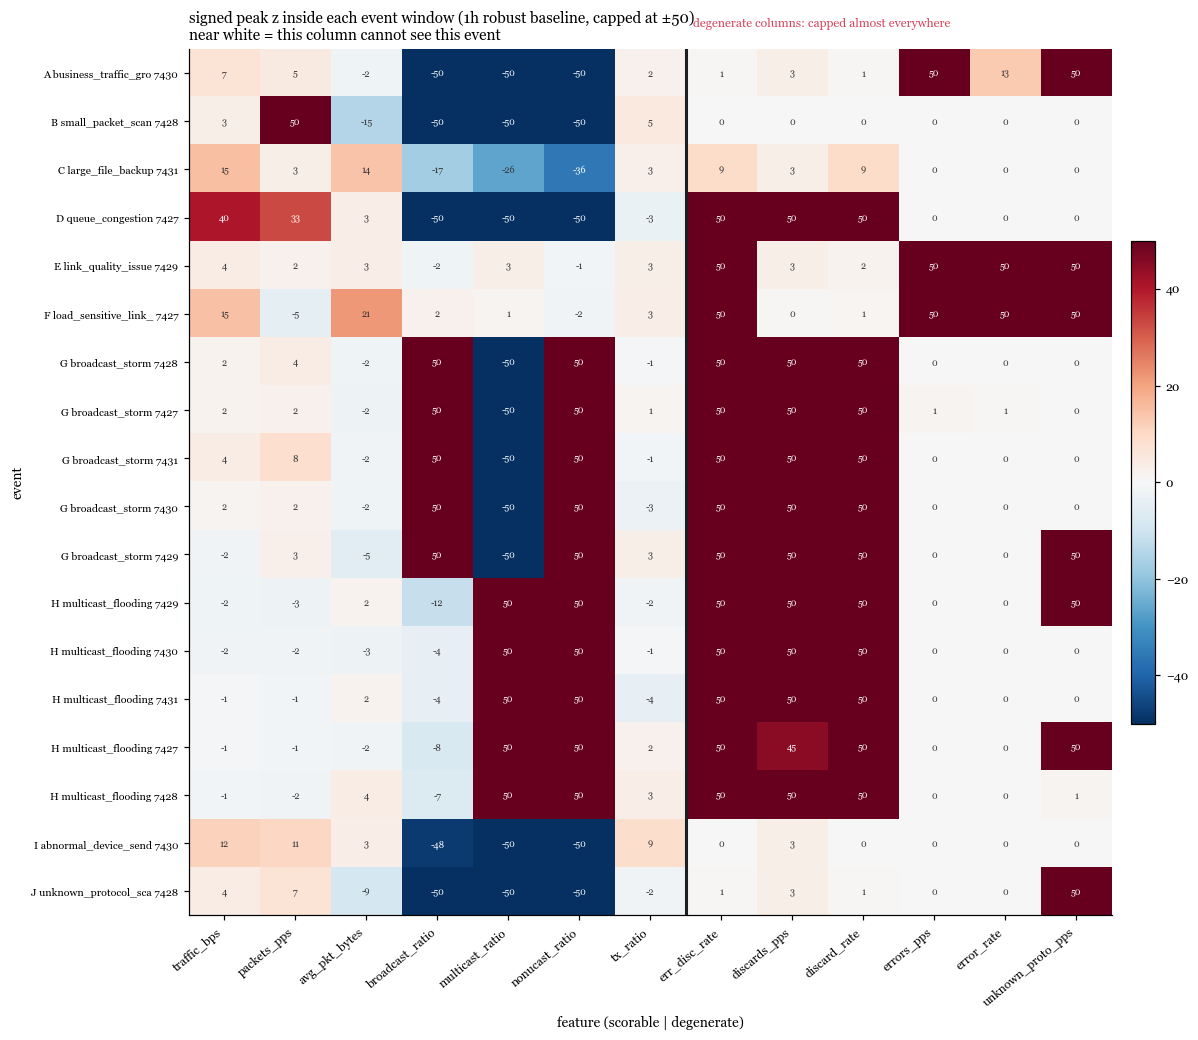

In [13]:
def signed_peak(s):
    """The value furthest from zero inside a window, keeping its sign.

    Sign matters here: broadcast_ratio swinging to +50 and to -50 are different events,
    and an unsigned peak would make them look identical.
    """
    s = s.dropna()
    return float(s.loc[s.abs().idxmax()]) if len(s) else np.nan


# Columns are grouped scorable first, degenerate second, so the two blocks can be read
# against each other: the right-hand block sits at the cap almost everywhere, which is
# what a collapsed denominator looks like rather than a detection.
ORDER = SCORABLE + DEGENERATE
peak = pd.DataFrame([
    {"ev": f"{e.event_id} {e.event_type[:20]} {e.port_id[-4:]}",
     **{c: signed_peak(tel.loc[(tel["port_id"] == e.port_id)
                               & tel["timestamp"].between(e.start, e.end), "z_" + c])
        for c in ORDER}}
    for e in events.itertuples()]).set_index("ev")

fig, ax = plt.subplots(figsize=(11, 0.42 * len(peak) + 2))
im = ax.imshow(peak, cmap="RdBu_r", vmin=-MAX_SCORE, vmax=MAX_SCORE, aspect="auto")
ax.axvline(len(SCORABLE) - 0.5, color="#1B1F23", lw=2.0)
ax.text(len(SCORABLE) - 0.4, -0.9, "degenerate columns: capped almost everywhere",
        fontsize=8, color=C["alert"], va="bottom")
ax.set_xticks(range(len(ORDER)), ORDER, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(peak)), peak.index, fontsize=7)
for i in range(peak.shape[0]):
    for j in range(peak.shape[1]):
        ax.text(j, i, f"{peak.iat[i, j]:.0f}", ha="center", va="center", fontsize=6,
                color="white" if abs(peak.iat[i, j]) > 28 else "#333333")
ax.grid(False)
ax.set(xlabel="feature (scorable | degenerate)", ylabel="event",
       title=f"signed peak z inside each event window (1h robust baseline, capped at ±{MAX_SCORE:.0f})\n"
             "near white = this column cannot see this event")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
fig.tight_layout(); plt.show()

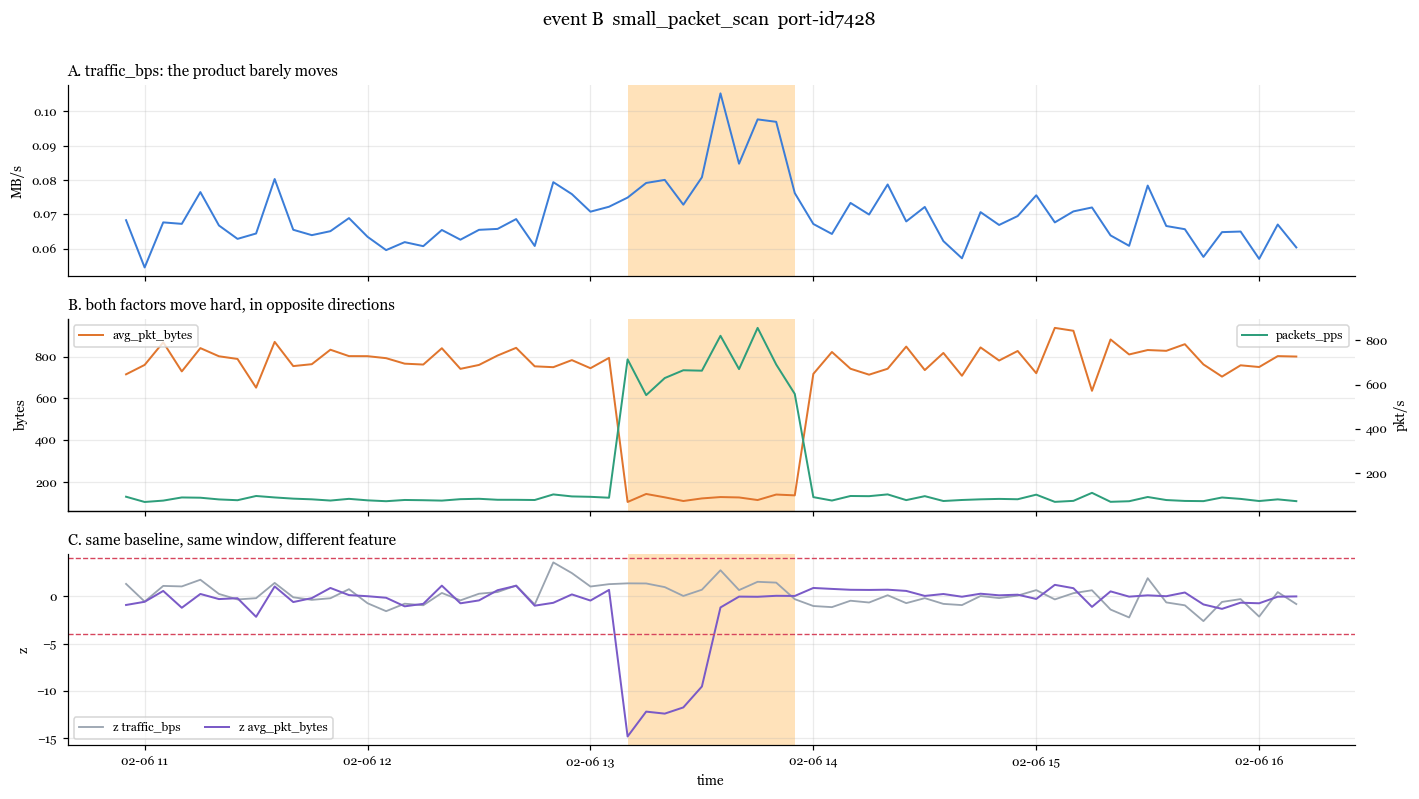

In [14]:
# Event B in close-up. Panel A is the product, panel B its two factors on twin axes,
# panel C the same baseline reading two different features over the same window.
eb = events[events["event_id"] == "B"].iloc[0]
pad = (eb.end - eb.start) * 3                        # show the event with context either side
w = tel[(tel["port_id"] == eb.port_id) & tel["timestamp"].between(eb.start - pad, eb.end + pad)]

fig, axes = plt.subplots(3, 1, figsize=(13, 7.2), sharex=True)
axes[0].plot(w["timestamp"], w["traffic_bps"] / 1e6, color=C["signal"], lw=1.3)
axes[0].set(ylabel="MB/s", title="A. traffic_bps: the product barely moves")

axes[1].plot(w["timestamp"], w["avg_pkt_bytes"], color=C["baseline"], lw=1.3, label="avg_pkt_bytes")
twin = axes[1].twinx(); twin.grid(False)             # the two factors differ by orders of magnitude
twin.plot(w["timestamp"], w["packets_pps"], color=C["peer"], lw=1.3, label="packets_pps")
twin.set_ylabel("pkt/s")
axes[1].set(ylabel="bytes", title="B. both factors move hard, in opposite directions")
axes[1].legend(loc="upper left"); twin.legend(loc="upper right")

axes[2].plot(w["timestamp"], w["z_traffic_bps"], color=C["muted"], lw=1.2, label="z traffic_bps")
axes[2].plot(w["timestamp"], w["z_avg_pkt_bytes"], color=C["score"], lw=1.3, label="z avg_pkt_bytes")
for level in (4, -4):
    axes[2].axhline(level, color=C["alert"], ls="--", lw=0.9)
axes[2].set(ylabel="z", xlabel="time", title="C. same baseline, same window, different feature")
axes[2].legend(loc="lower left", ncol=2)

for ax in axes:
    shade(ax, w["timestamp"], w["is_event"])
fig.suptitle(f"event B  small_packet_scan  {eb.port_id}", y=1.002)
fig.tight_layout(); plt.show()

### 探索練習：換一種「峰值」的定義

**任務**：把 `signed_peak()` 換成「超過 4 的樣本數」。

```python
def signed_peak(s):
    return float((s.abs() > 4).sum())
```

觀察：

- 哪些 event 的排名掉下來了？
- 短而尖的 event 與長而緩的 event，哪一種吃虧？

**討論**：改成數樣本數，衡量的就從「最極端那一瞬間」變成「這個 event 有多持久」。event G 與 H 各佔五列，因為它們同時打在 5 個 port 上。單看 `broadcast_ratio` 那一欄的符號：它不是 broadcast storm 的獨特指紋，其他 event 也會讓這個比率擺到相反的極端，真正識別 G 的是組合。

## 第 10 步：leave-one-out ablation 與 greedy forward selection

固定一組偵測規則：跨 feature 取最大 $|z|$、threshold 4、連續 2 筆確認。先量必須抓到的 window recall，然後一次拿掉一欄再量一次，差值就是那一欄的 **marginal contribution**。

第二個診斷分辨零貢獻的兩種意思：**solo hit** 大於零而 marginal 為零，代表冗餘；兩者皆為零，代表這個月真的什麼都沒抓到。

只在第 4 步判定為 `SCORABLE` 的欄位上跑。degenerate 的欄位 z 幾乎恆定爆表，放進來會用天量 false alarm 換到一個假的滿分，B 圖把那個價碼單獨列出來。

In [15]:
TH, N_CONSEC = 4.0, 2

# Precompute everything the audit loop needs as plain numpy arrays. The loop runs once
# per candidate subset, so anything left as a pandas operation gets paid for many times.
port_arr = tel["port_id"].to_numpy()
ts = tel["timestamp"].to_numpy()
truth = np.zeros(len(tel), bool)                     # True on every sample inside any event
for e in events.itertuples():
    truth |= (port_arr == e.port_id) & (ts >= e.start.to_datetime64()) & (ts <= e.end.to_datetime64())
windows = [np.flatnonzero((port_arr == e.port_id) & (ts >= e.start.to_datetime64())
                          & (ts <= e.end.to_datetime64())) for e in incidents.itertuples()]
days = (tel["timestamp"].max() - tel["timestamp"].min()).total_seconds() / 86400
zabs = {c: np.nan_to_num(tel["z_" + c].abs().to_numpy(), nan=-1.0) for c in FEATURES}


def audit(cols):
    """Score one feature subset: cross-feature max |z|, N-consecutive confirm, then measure.

    Returns (event windows caught, false alarms per day). Recall is counted at window
    level because catching an event once is operationally enough; the cost is counted
    per sample outside any event, because that is what reaches the on-call engineer.
    """
    if not cols:
        return 0, 0.0
    breach = pd.Series(np.vstack([zabs[c] for c in cols]).max(axis=0) > TH)
    ok = np.ones(len(breach), bool)
    for k in range(N_CONSEC):                        # require N consecutive breaches per port
        ok &= breach.groupby(port_arr).shift(k).fillna(False).to_numpy().astype(bool)
    return sum(ok[i].any() for i in windows), ok[~truth].sum() / days


full_recall, full_fp = audit(SCORABLE)

# Leave one out: how much recall disappears, and how much daily noise disappears with it.
abl = pd.DataFrame([{"feature": c,
                     "solo": audit([c])[0],
                     "marginal": full_recall - audit([x for x in SCORABLE if x != c])[0],
                     "fp_added": full_fp - audit([x for x in SCORABLE if x != c])[1]}
                    for c in SCORABLE]).sort_values(["solo", "marginal"]).reset_index(drop=True)

# Greedy forward selection: repeatedly add the column that buys the most recall for the
# least added noise. The curve usually flattens well before the full set is in.
picked, pool, path = [], list(SCORABLE), []
while pool:
    trial = {c: audit(picked + [c]) for c in pool}
    best = max(pool, key=lambda c: (trial[c][0], -trial[c][1]))
    picked.append(best); pool.remove(best)
    path.append({"n": len(picked), "added": best,
                 "recall": trial[best][0], "fp_per_day": trial[best][1]})
path = pd.DataFrame(path)

# What the degenerate columns would cost if someone added them "just in case".
degen_cost = pd.DataFrame([{"feature": c, "solo": audit([c])[0],
                            "fp_added": audit(SCORABLE + [c])[1] - full_fp} for c in DEGENERATE])

print(f"all {len(SCORABLE)} scorable features: {full_recall}/{len(windows)} incident windows, "
      f"{full_fp:.1f} false alarms/day")

all 7 scorable features: 15/16 incident windows, 10.9 false alarms/day


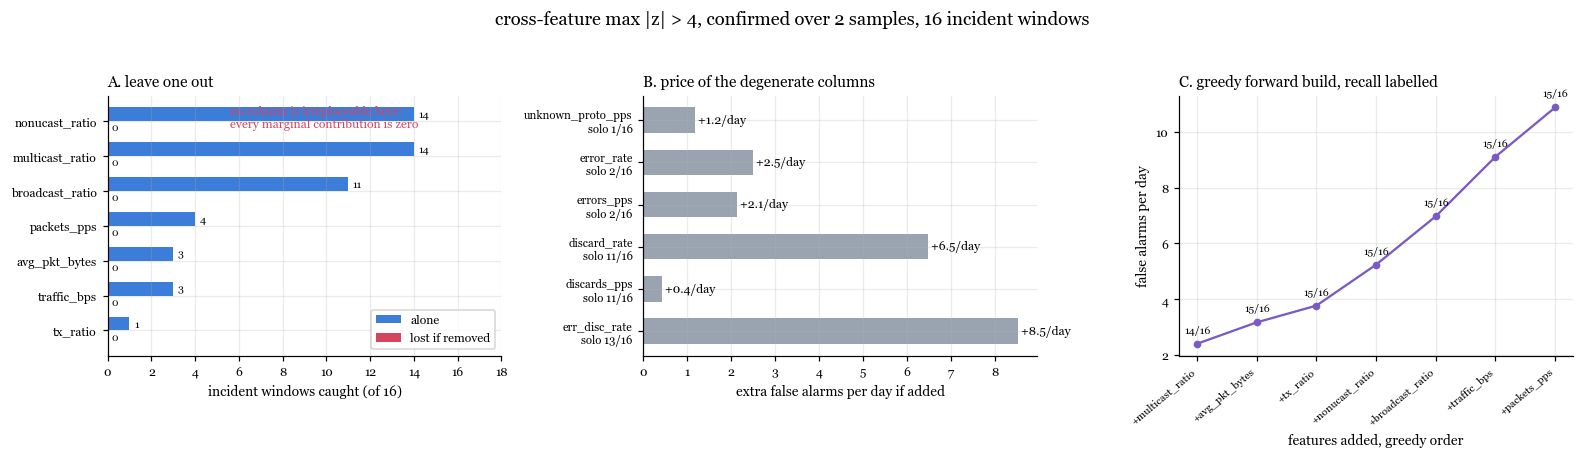

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.0))
y = np.arange(len(abl))
axes[0].barh(y + 0.19, abl["solo"], height=0.38, color=C["signal"], label="alone")
axes[0].barh(y - 0.19, abl["marginal"], height=0.38, color=C["alert"], label="lost if removed")
for n, (solo, marginal) in enumerate(zip(abl["solo"], abl["marginal"])):
    axes[0].text(solo + 0.2, n + 0.19, str(solo), va="center", fontsize=7)
    axes[0].text(marginal + 0.2, n - 0.19, str(marginal), va="center", fontsize=7)
axes[0].set_yticks(y, abl["feature"], fontsize=8)
axes[0].set(xlim=(0, len(windows) + 2), xlabel=f"incident windows caught (of {len(windows)})",
            title="A. leave one out")
axes[0].legend(loc="lower right")
if abl["marginal"].max() == 0:
    # A flat red series is the finding, not a bug: at this threshold every window one
    # column catches is caught by another column too.
    axes[0].text(len(windows) * 0.35, len(abl) - 1.2,
                 "no column is irreplaceable here:\nevery marginal contribution is zero",
                 fontsize=8, color=C["alert"])

axes[1].barh(np.arange(len(degen_cost)), degen_cost["fp_added"], color=C["muted"], height=0.6)
for n, v in enumerate(degen_cost["fp_added"]):
    axes[1].text(v, n, f" +{v:.1f}/day", va="center", fontsize=8)
axes[1].set_yticks(range(len(degen_cost)),
                   [f"{t.feature}\nsolo {t.solo}/{len(windows)}" for t in degen_cost.itertuples()],
                   fontsize=7.5)
axes[1].set(xlabel="extra false alarms per day if added",
            title="B. price of the degenerate columns")

axes[2].plot(path["n"], path["fp_per_day"], marker="o", ms=4, color=C["score"])
for t in path.itertuples():
    axes[2].annotate(f"{t.recall}/{len(windows)}", (t.n, t.fp_per_day), fontsize=7,
                     textcoords="offset points", xytext=(0, 7), ha="center")
axes[2].set_xticks(path["n"], [f"+{a}" for a in path["added"]], rotation=40, ha="right", fontsize=7)
axes[2].set(xlabel="features added, greedy order", ylabel="false alarms per day",
            title="C. greedy forward build, recall labelled")
fig.suptitle(f"cross-feature max |z| > {TH:.0f}, confirmed over {N_CONSEC} samples, "
             f"{len(windows)} incident windows", y=1.03)
fig.tight_layout(); plt.show()

### 探索練習：ablation 的判定門檻

**任務**：把 `TH` 改成 3.0、`N_CONSEC` 改成 3，重新執行這兩格。

```python
TH, N_CONSEC = 3.0, 3
```

觀察：

- 哪幾欄的 marginal contribution 變了？
- greedy 的前兩名還是同樣那兩欄嗎？

**討論**：如果一個 feature 的價值取決於 threshold 怎麼設，那它的「貢獻」到底是什麼意思？跨 feature 目前取 `max`，換成加權平均或投票會得到另一組結論。greedy forward selection 只走一條路徑，窮舉所有子集才是完整的核算。selection 也是把五個 port 混在一起選的，不同 role 的 port 最佳組合不一定相同。

## 第 11 步：anomaly taxonomy

| 形狀 | 訊號長什麼樣 | 本資料集的例子 | 誰來修 |
|---|---|---|---|
| Point | 單一讀數遠離線條 | D `queue_congestion` | 任何 baseline |
| Contextual | 選對 feature 才顯得不尋常 | B `small_packet_scan` | feature selection（本 lab） |
| Collective | 沒有單點極端，群體一起動 | G `broadcast_storm` | feature 加上跨指標推理 |
| Change point | 水位本身永久移動 | A `business_traffic_growth` | change-point detection（Lab 02） |

Contextual 與 collective 由 feature 解決，不是由更精細的 baseline 解決。一個只調 baseline 的 pipeline，對這張表上大約一半的 anomaly 結構性地盲目。

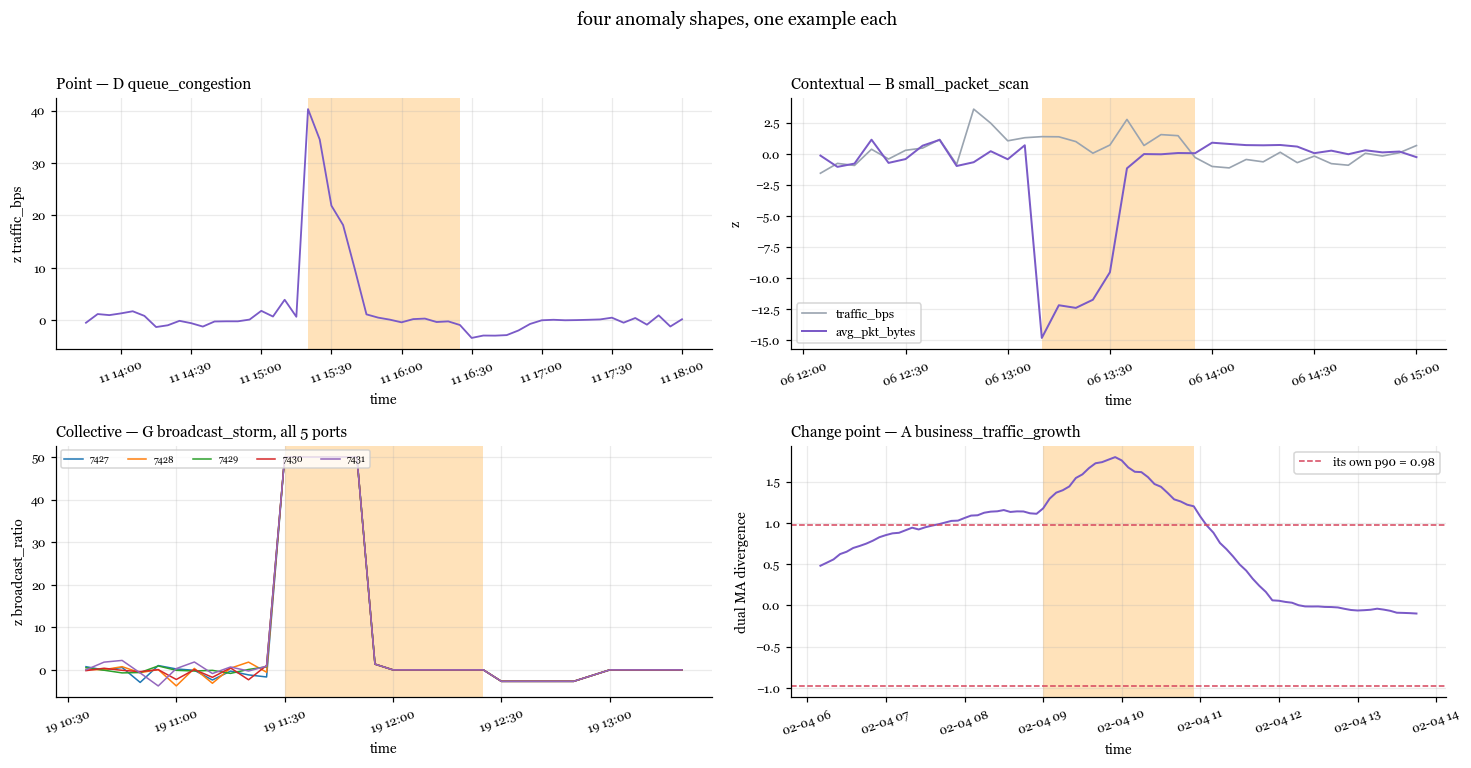

In [17]:
def dual_ma(v, short, long):
    """Change-point statistic: relative gap between a fast and a slow moving average.

    A stable series keeps the two averages together. A level shift makes the fast one
    move first, and the gap between them is the signal. This asks a different question
    from a z-score: not how far this sample sits from the level, but whether the level moved.
    """
    fast = v.rolling(short, min_periods=short // 2).mean()
    slow = v.rolling(long, min_periods=long // 2).mean()
    return (fast - slow) / (slow.abs() + 1e-9)


def window_of(e, pad_mult=1.5):
    """Rows for one event plus context on both sides, so the run-up is visible."""
    pad = (e.end - e.start) * pad_mult
    return tel[(tel["port_id"] == e.port_id) & tel["timestamp"].between(e.start - pad, e.end + pad)]


fig, axes = plt.subplots(2, 2, figsize=(13.5, 6.8))

ed = events[events.event_id == "D"].iloc[0]
w = window_of(ed)
axes[0, 0].plot(w["timestamp"], w["z_traffic_bps"], color=C["score"], lw=1.2)
axes[0, 0].set(ylabel="z traffic_bps", title="Point — D queue_congestion")

# Contextual: the same window read through two features, one blind and one not.
eb = events[events.event_id == "B"].iloc[0]
w = window_of(eb)
axes[0, 1].plot(w["timestamp"], w["z_traffic_bps"], color=C["muted"], lw=1.1, label="traffic_bps")
axes[0, 1].plot(w["timestamp"], w["z_avg_pkt_bytes"], color=C["score"], lw=1.3, label="avg_pkt_bytes")
axes[0, 1].legend(loc="lower left")
axes[0, 1].set(ylabel="z", title="Contextual — B small_packet_scan")

# Collective: no single port is an outlier against its peers, they all move together.
g = events[events.event_id == "G"]
g0, g1 = g["start"].min(), g["end"].max()
for pid in ports:
    w = tel[(tel["port_id"] == pid) & tel["timestamp"].between(g0 - (g1 - g0), g1 + (g1 - g0))]
    axes[1, 0].plot(w["timestamp"], w["z_broadcast_ratio"], lw=1.0, label=pid[-4:])
axes[1, 0].axvspan(g0, g1, color=C["truth"], alpha=0.3, lw=0)
axes[1, 0].legend(fontsize=6, ncol=5, loc="upper left")
axes[1, 0].set(ylabel="z broadcast_ratio", title="Collective — G broadcast_storm, all 5 ports")

# Change point: the threshold comes from the series' own history, not from elsewhere.
ea = events[events.event_id == "A"].iloc[0]
cp = tel[tel["port_id"] == ea.port_id].sort_values("timestamp").copy()
cp["dual_ma"] = dual_ma(cp["traffic_bps"], WINDOW, 6 * WINDOW)
pad = (ea.end - ea.start) * 1.5
w = cp[cp["timestamp"].between(ea.start - pad, ea.end + pad)]
axes[1, 1].plot(w["timestamp"], w["dual_ma"], color=C["score"], lw=1.3)
p90 = cp["dual_ma"].abs().quantile(0.9)
axes[1, 1].axhline(p90, color=C["alert"], ls="--", lw=1.0, label=f"its own p90 = {p90:.2f}")
axes[1, 1].axhline(-p90, color=C["alert"], ls="--", lw=1.0)
axes[1, 1].legend()
axes[1, 1].set(ylabel="dual MA divergence", title="Change point — A business_traffic_growth")

for ax, e in zip([axes[0, 0], axes[0, 1], axes[1, 1]], [ed, eb, ea]):
    ax.axvspan(e.start, e.end, color=C["truth"], alpha=0.3, lw=0)
for ax in axes.flat:
    ax.set_xlabel("time"); ax.tick_params(axis="x", labelrotation=20)
fig.suptitle("four anomaly shapes, one example each", y=1.02)
fig.tight_layout(); plt.show()

### 探索練習：change point 的兩個 window

**任務**：把 `dual_ma` 的 `long` 從 `6 * WINDOW` 改成 `24 * WINDOW`。

```python
cp["dual_ma"] = dual_ma(cp["traffic_bps"], WINDOW, 24 * WINDOW)
```

觀察：

- 訊號更乾淨還是更遲鈍？
- p90 這條線跟著往哪個方向移動？

**討論**：這張分類表決定的是「哪一層該修」。contextual 與 collective 要回到 feature，point 與 change point 才輪到 baseline，搞錯層級，調再久的 baseline 也不會動。

## 第 12 步：存檔

只寫下游會用到的欄位：識別欄、feature、以及每個 feature 的 robust z。baseline 的 center 與 scale 不寫出去，因為重算它們正是 Lab 02 的主題。

In [18]:
# The contract with Lab 02. Keeping the intermediate baseline columns would triple the
# file for numbers the next notebook recomputes anyway.
keep = (["timestamp", "device_id", "port_id", "port_role", "event_label", "event_id", "is_event"]
        + FEATURES + [f"z_{c}" for c in FEATURES])
out = OUT / "features.csv"
tel[keep].to_csv(out, index=False, float_format="%.6g")

print(f"{out}  ({out.stat().st_size / 1e6:.1f} MB)")
print(f"{len(tel):,} rows x {len(keep)} columns")
print(f"scorable   {SCORABLE}")
print(f"degenerate {DEGENERATE}   <- Lab 02 handles these with a fixed threshold")

/Users/kevin/Library/CloudStorage/GoogleDrive-kevin880987@gmail.com/我的雲端硬碟/workshop/workbench/project/202608-aia-network-monitoring-aiops/aiops-anomaly-zero-to-hero/outputs/workshop/features.csv  (9.9 MB)
43,200 rows x 33 columns
scorable   ['traffic_bps', 'packets_pps', 'avg_pkt_bytes', 'broadcast_ratio', 'multicast_ratio', 'nonucast_ratio', 'tx_ratio']
degenerate ['err_disc_rate', 'discards_pps', 'discard_rate', 'errors_pps', 'error_rate', 'unknown_proto_pps']   <- Lab 02 handles these with a fixed threshold


### 探索練習：契約裡少了什麼

**任務**：把 `float_format` 拿掉，比較檔案大小。

```python
tel[keep].to_csv(out, index=False)
```

觀察：

- 檔案大幾倍？
- Lab 02 的結論有任何一格因此改變嗎？

**討論**：`SCORABLE` 與 `DEGENERATE` 這兩份名單目前只印在畫面上，沒有寫進檔案。要讓 Lab 02 不必重新判斷一次，它們也該是契約的一部分。baseline 的 center 與 scale 沒有寫出去，因為重算它們正是 Lab 02 的主題。

## 人類驗證點 #1：feature 由你設計

本 lab 裡的每一個 feature、`WINDOW` 的長度、degenerate 的 0.5 界線，都是由你設計的，不是演算法自動選出來的。

**任何 feature 演算法都算得出來，但它不知道哪些 feature 對你的網路有意義。**

在繼續之前，問自己四件事：

1. 你選的 `WINDOW`（1 小時）適合你的業務節奏嗎？24/7 的資料中心和朝九晚五的辦公室網路，baseline 的形狀完全不同。第 6 步的 autocorrelation 給了下限，上限要由你決定。
2. `error_rate = errors / packets` 這個公式合理嗎？如果某個 port 幾乎沒有流量，分母趨近於零會發生什麼？Lab 02 的 minimum volume gate 就是為了這個。
3. 第 10 步說有幾欄的 marginal contribution 是零。你會把它們刪掉，還是留著？留著的理由是什麼，這個理由是誰在什麼時候會重新檢視？
4. 第 1 步把 18 個 window 切成「必須抓到」與「必須安靜」兩堆。你的環境裡那份 change calendar 存在嗎，還是抑制的決定散落在每個人的記憶裡？

這些判斷要由你來做。

## 練習與檢查點

完成本 lab 後，你應該能回答四個問題：

1. 把第 7 步的 `ev` 從 event D 換成 event C，重新執行。rolling mean 與 rolling robust 的差距變大還是變小？為什麼？
2. `avg_pkt_bytes` 升高通常代表什麼業務行為？降低呢？（提示：大量小封包與少量大封包的差異）
3. 為什麼 rolling statistics 必須逐 port 獨立計算，而不能把五個 port 混在一起？
4. 第 9 步證明了 event B 對 `traffic_bps` 不可見。用同樣的邏輯，想一個對 `avg_pkt_bytes` 也不可見的故障形狀。

---

> 「`floor_of()` 解決了什麼問題？如果不用它，哪一欄的 score 最先失控？」

> 「為什麼 `tx_ratio` 可能在半夜出現極端值，即使網路完全正常？」

> 「如果你的網路有明顯的上班與下班流量模式，1 小時 window 與 1 天 window 各有什麼問題？」

## 收束

這一節做完之後手上握著三樣東西，Lab 02 全部要用：

1. 一組候選 feature，以及量出來的 marginal contribution 與每日 false alarm 代價。
2. 兩個結構性缺口。contextual 與 collective anomaly 靠 feature 解決，degenerate 的欄位靠 fixed threshold 解決。
3. 量出來的資料契約：cadence、1 小時 window 的樣本數、base rate 0.66%、最短 event 8 筆。最後這個數字直接限制 Lab 02 的 confirmation 長度。

**下一步 → Lab 02：Baseline anomaly detection 與 alerting。**